In [1]:
here::i_am("blood_trajectory/manual_iterativeLSI.ipynb")

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(uwot))
suppressPackageStartupMessages(library(parallel))

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [2]:
args = list()
args$outdir = file.path(io$basedir, 'results/epiblast_blood') 
args$trajectory_name <- "epiblast_blood"

In [8]:
sample_metadata = fread(file.path(args$outdir,sprintf("%s_sample_metadata.txt.gz",args$trajectory_name)))

latent = fread(sprintf('%s/scVI_latent.csv', args$outdir))[-1,-1] %>%
    setnames(c(paste0('VI_', 1:25))) %>% 
    .[,cell:=sample_metadata$cell] %>%
    as.data.frame() %>% tibble::column_to_rownames('cell')

LSI = fread(sprintf("%s/peakVI_latent.csv",args$outdir))[-1,-1] %>%
    .[,cell:=sample_metadata$cell] %>%
    as.data.frame() %>% tibble::column_to_rownames('cell')

In [9]:
# Check if cells are in the same order
summary(rownames(latent) == rownames(LSI))

   Mode    TRUE 
logical   12686 

V12        V4       V14       V21       V22        V6       V17       V19 
0.6228914 0.6091134 0.6044652 0.5715272 0.5576918 0.5560601 0.5551590 0.5263689 
       V9       V11        V2       V25       V20       V10       V16        V8 
0.5147416 0.4891230 0.4682002 0.4658287 0.4655456 0.4605918 0.4522809 0.4518117 
       V5       V26        V3       V23       V15       V13       V24        V7 
0.4159003 0.3889507 0.3632181 0.3570619 0.3564224 0.2746849 0.2654658 0.2268239 
      V18 
0.2259397

[1] 25

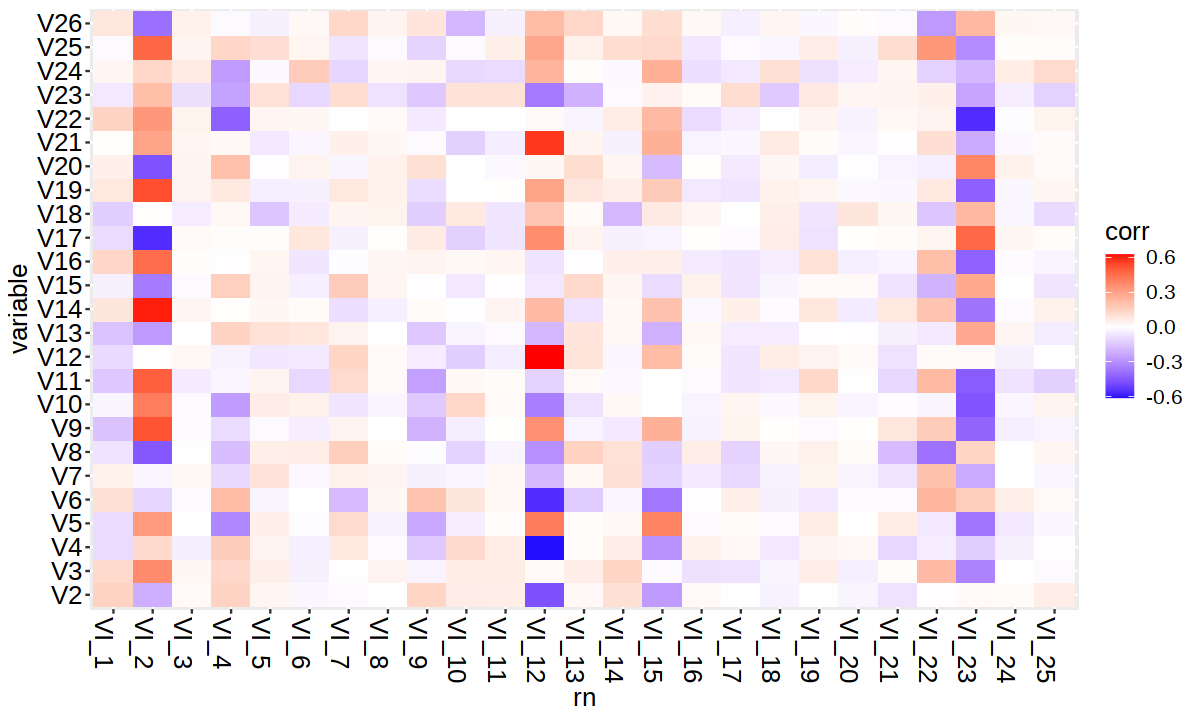

In [11]:
# Remove highly correlated LSIs
cor = cor(latent, LSI)
corr.dt = as.data.table(cor, keep.rownames=T) %>% 
    melt(id = "rn", value.name = "corr") %>% 
    .[,rn:=factor(rn, levels=paste0('VI_', 1:25))]
options(repr.plot.width=10, repr.plot.height=6)
ggplot(corr.dt, aes(rn, variable, fill=corr)) + 
    geom_tile() + 
    scale_fill_gradient2(low='blue', mid='white', high='red') + 
    theme(text=element_text(color='black', size=15), 
         axis.text.x = element_text(color='black', size=15, angle=-90, hjust=0, vjust=1),
         axis.text.y = element_text(color='black', size=15))

maxcor = apply(abs(cor), 2, max)
maxcor[order(-maxcor)]
keep = colnames(cor[,maxcor<0.9])
length(keep)

# No LSI have more than 0.9 correlation with latent spaces

In [15]:
get_umap = function(PC1 = NULL, PC2 = NULL, n_neighbors = 25, min_dist=0.3, plot=FALSE){  
    joint_dimred = cbind(PC1, PC2)
    joint_dimred = apply(joint_dimred, 2, scale)
    rownames(joint_dimred) = sample_metadata$cell
    
    # Calculate UMAP
    umap.mtx = umap(joint_dimred, 
                    n_neighbors = n_neighbors,
                    min_dist = min_dist)

    # Fetch UMAP coordinates
    umap.dt <- umap.mtx %>% as.data.table(keep.rownames=T) %>% setnames('rn', 'cell') %>% 
      setnames(c("cell", "UMAP1","UMAP2")) %>%
      merge(.,sample_metadata[,c('cell', 'celltype', 'stage', 'sample')], by='cell')

    # Plot umap
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=stage)) + 
        geom_point() + 
        ggtitle('stage') + 
        scale_colour_manual(values=opts$stage.colors) + 
        theme_void() + 
        theme(legend.position="none")
    
    options(repr.plot.width=20, repr.plot.height=6)
    
    if(plot==TRUE){ggarrange(p1, p2)}
    else{return(umap.dt)}
    
}

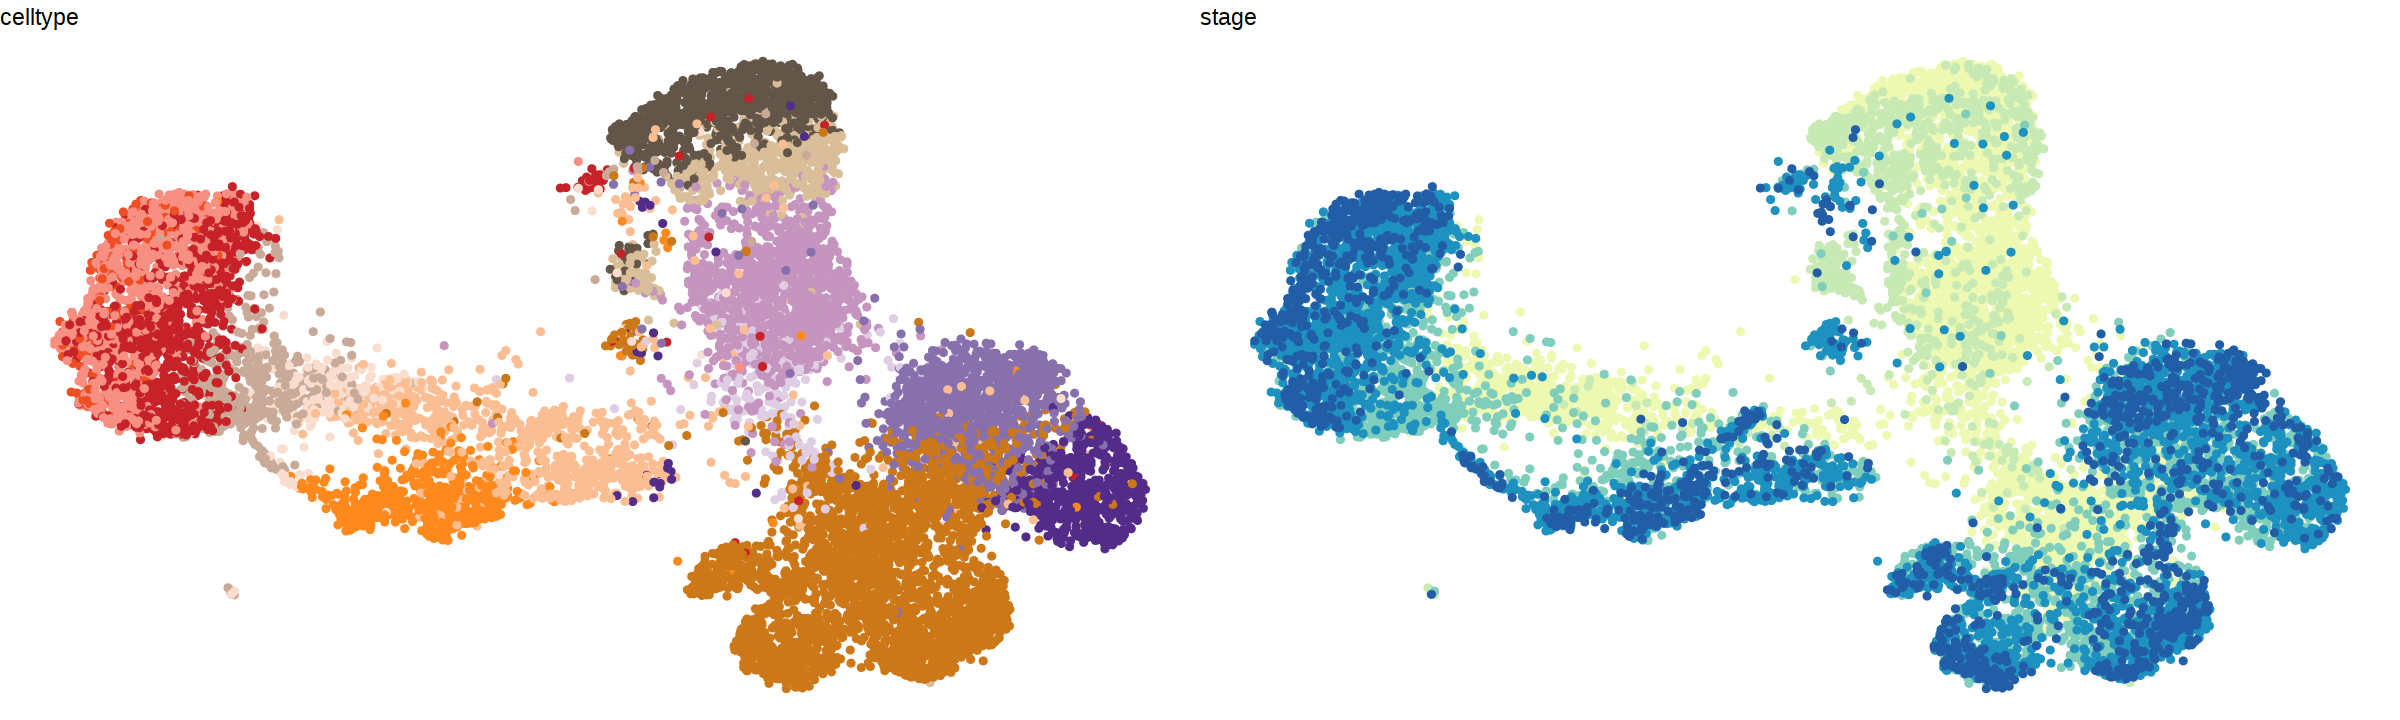

In [16]:
get_umap(PC1 = latent, PC2 = LSI, n_neighbors =  30, min_dist= 0.3, plot=TRUE)

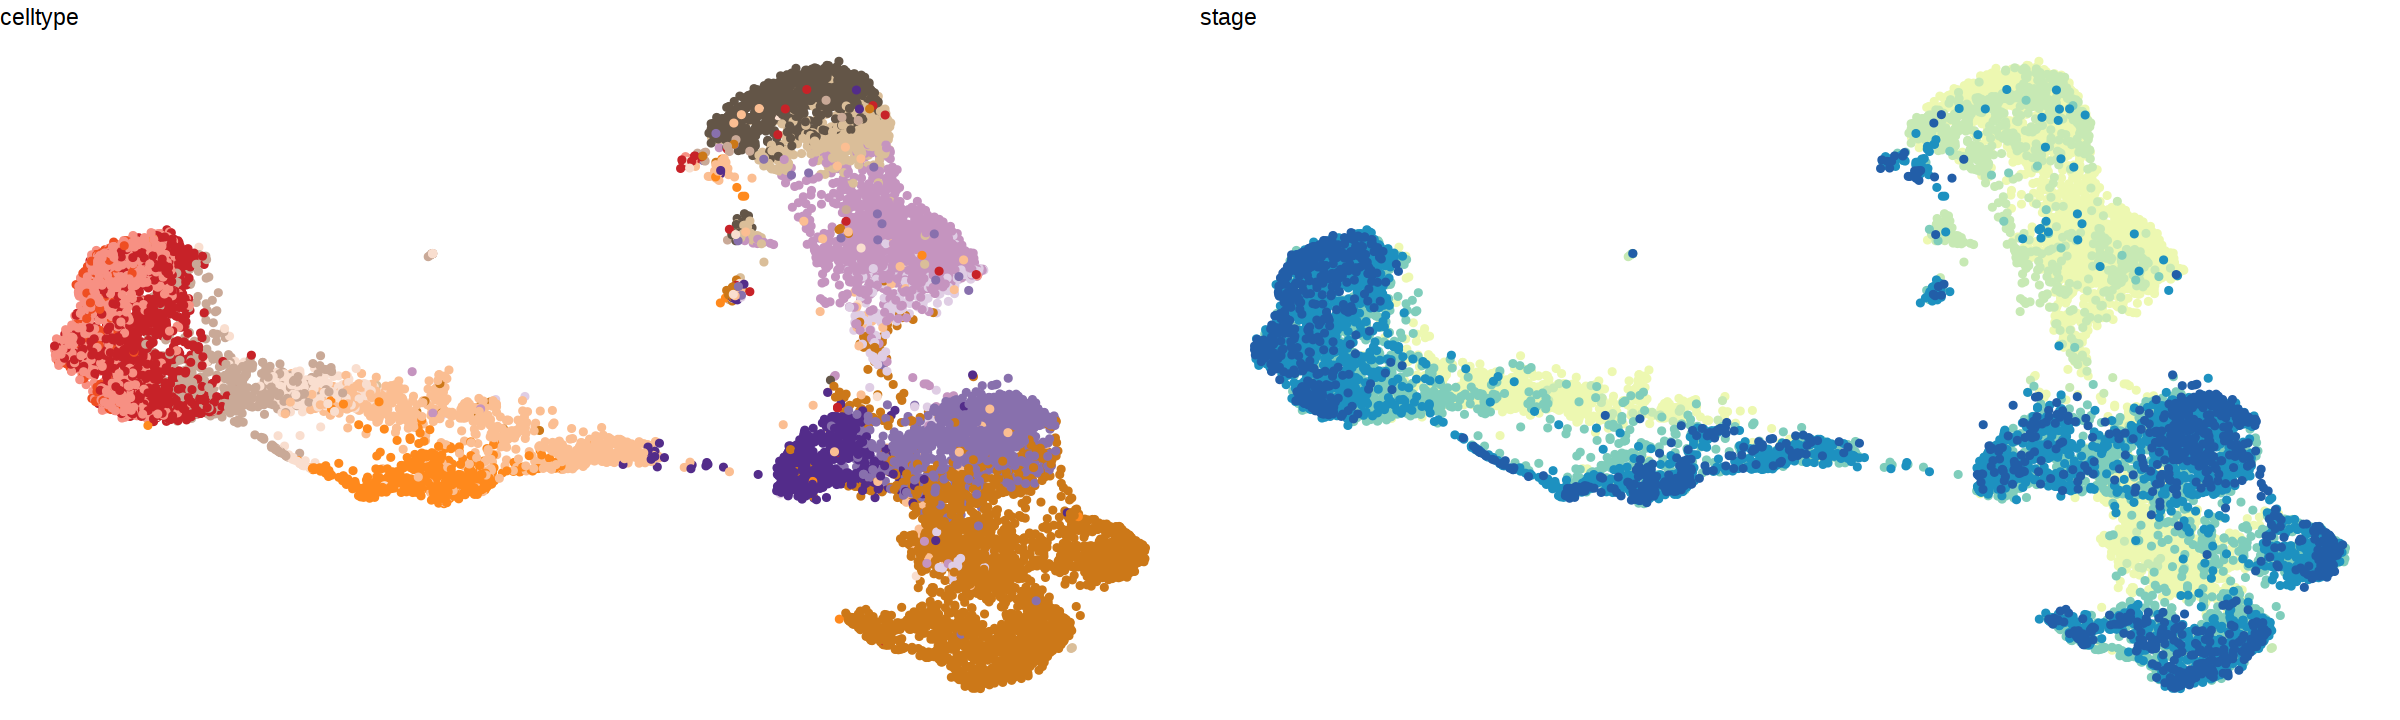

In [17]:
get_umap(PC1 = latent, PC2 = LSI, n_neighbors = 30, min_dist= 0.1, plot=TRUE)

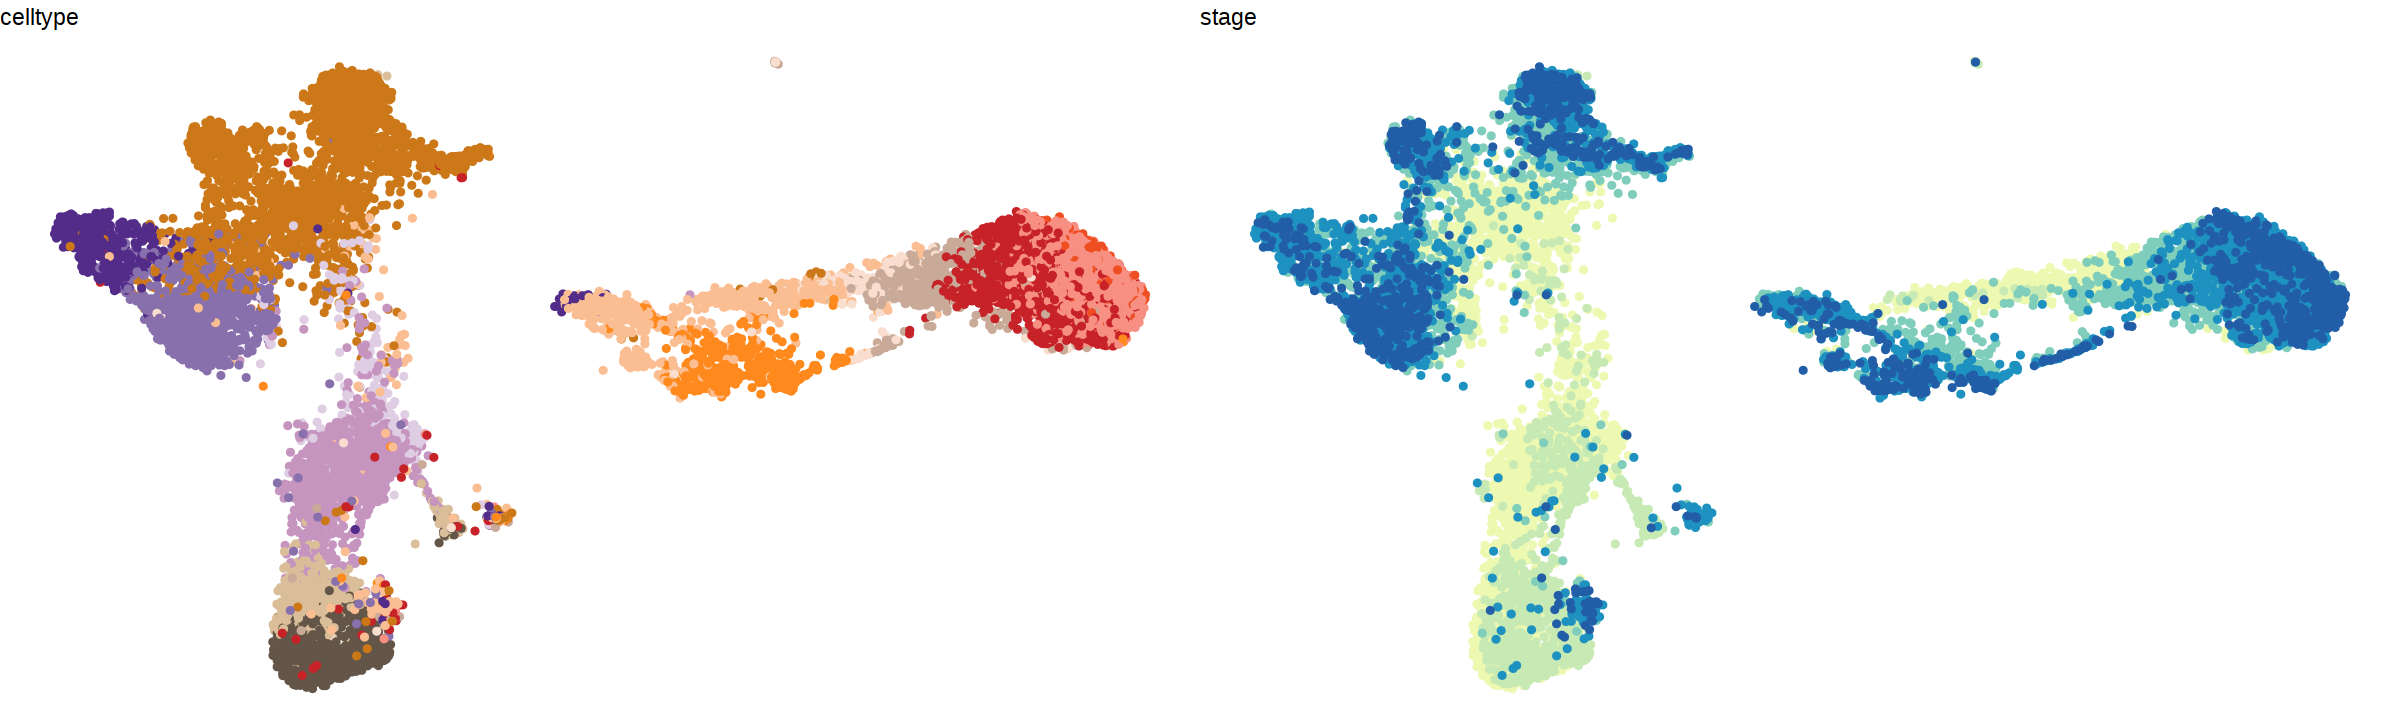

In [19]:
get_umap(PC1 = latent, PC2 = LSI[,1:10], n_neighbors = 30, min_dist= 0.1, plot=TRUE)